In [32]:
#importation de data set
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


df = pd.read_csv("../data/raw/adn_dataset.csv") 
df.head(5)

,sequence,label
0,MPATSSIITIIAVAACLLLLVADAHAQQQCNWQYGLTTMDIRCSVR...,0
1,MRRKMKLFLFLLLVINICRSAAANGDECPKFCKCAPDPVQPTSKLL...,0
2,MAFIRQAPFLRCLPLVLLCILTPTLIQTIHQDAMLTSSMKCHYDAE...,0
3,EKTEYRSEVEEIQQEDFLPLQNTTISNLTLTANKIQILQPQSFLHL...,0
4,MSFKHPSSLFPSLVMAFLLPLTLQAFQGDSMEIVSSGLHTGSVRRG...,0


In [19]:
# corrigé la structure du dataset
sequences = []
labels = []

with open("../data/raw/adn_data.txt", "r") as f:
    lines = f.read().splitlines()

# parcourir 2 lignes à la fois
for i in range(0, len(lines), 2):
    label = lines[i]
    sequence = lines[i+1]
    
    labels.append(label)
    sequences.append(sequence)

import pandas as pd

df = pd.DataFrame({
    "sequence": sequences,
    "label": labels
})

df.head()

,sequence,label
0,40,2
1,0,47
2,MRRKMKLFLFLLLVINICRSAAANGDECPKFCKCAPDPVQPTSKLL...,MPATSSIITIIAVAACLLLLVADAHAQQQCNWQYGLTTMDIRCSVR...
3,EKTEYRSEVEEIQQEDFLPLQNTTISNLTLTANKIQILQPQSFLHL...,MAFIRQAPFLRCLPLVLLCILTPTLIQTIHQDAMLTSSMKCHYDAE...
4,MTKPNSLIFYCIIVLGLTLMKIQLSEECELIIKRPNANLTRVPKDL...,MSFKHPSSLFPSLVMAFLLPLTLQAFQGDSMEIVSSGLHTGSVRRG...


In [33]:
# structure du dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sequence  87 non-null     str  
 1   label     87 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.5 KB


In [34]:
df.shape

(87, 2)

In [35]:
df.columns

Index(['sequence', 'label'], dtype='str')

In [36]:
# vérification des valeurs nulles
df.isnull().sum()

sequence    0
label       0
dtype: int64

In [37]:
 #verifier les valeurs doubles
df.duplicated().sum()

np.int64(0)

In [38]:
print(df.columns)

Index(['sequence', 'label'], dtype='str')


In [42]:
df.duplicated(subset=["sequence"]).sum()

np.int64(0)

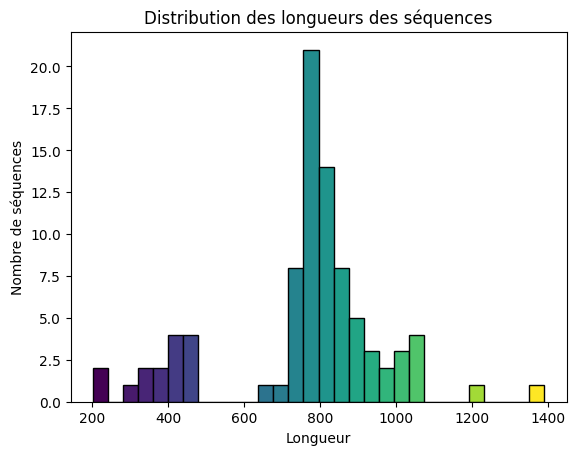

In [39]:
df["length"] = df["sequence"].apply(len)

n, bins, patches = plt.hist(df["length"], bins=30, edgecolor="black")

colors = plt.cm.viridis(np.linspace(0, 1, len(patches)))
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

plt.title("Distribution des longueurs des séquences")
plt.xlabel("Longueur")
plt.ylabel("Nombre de séquences")
plt.show()


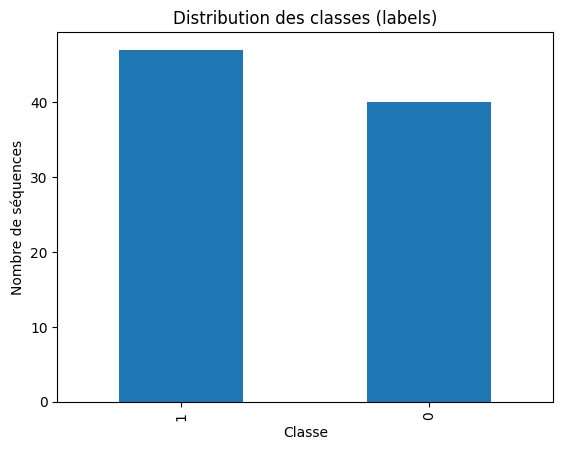

In [40]:
# Pour voir si ton dataset est équilibré
df["label"].value_counts().plot(kind="bar")
plt.title("Distribution des classes (labels)")
plt.xlabel("Classe")
plt.ylabel("Nombre de séquences")
plt.show()

In [41]:
df.head()
df.columns
df["label"].unique()[:10]

array([0, 1])

In [29]:
df.to_csv(f"../data/processed/adn_data_cleaned.csv", index=False)

print("Données sauvegardées dans data/processed/adn_data_cleaned.csv")

Données sauvegardées dans data/processed/adn_data_cleaned.csv


In [30]:
df.head()

,sequence,label,length
0,40,2,2
1,0,47,1
2,MRRKMKLFLFLLLVINICRSAAANGDECPKFCKCAPDPVQPTSKLL...,MPATSSIITIIAVAACLLLLVADAHAQQQCNWQYGLTTMDIRCSVR...,1221
3,EKTEYRSEVEEIQQEDFLPLQNTTISNLTLTANKIQILQPQSFLHL...,MAFIRQAPFLRCLPLVLLCILTPTLIQTIHQDAMLTSSMKCHYDAE...,742
4,MTKPNSLIFYCIIVLGLTLMKIQLSEECELIIKRPNANLTRVPKDL...,MSFKHPSSLFPSLVMAFLLPLTLQAFQGDSMEIVSSGLHTGSVRRG...,795
